![](https://ga-dash.s3.amazonaws.com/production/assets/logo-9f88ae6c9c3871690e33280fcf557f33.png) 

# Introduction to Time Series in Pandas

_Authors:_ Tim Book, Riley Dallas, Matt Brems

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

## Stock Data
We'll use [Yahoo! Finance](https://finance.yahoo.com/quote/AAPL) to get a few years worth of stock prices from Apple, Inc. (AAPL)

In [7]:
# Load data.
aapl = pd.read_csv('data/AAPL.csv')
aapl.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-08-08,206.050003,207.809998,204.520004,207.250000,201.371887,22525500
1,2018-08-09,209.529999,209.779999,207.199997,208.880005,202.955643,23492600
2,2018-08-10,207.360001,209.100006,206.669998,207.529999,202.351089,24611200
3,2018-08-13,209.309998,210.949997,207.699997,208.869995,203.657639,25890900
4,2018-08-14,210.160004,210.559998,208.259995,209.750000,204.515747,20748000


In [8]:
# Change date column to be datetime dtype.
aapl['Date'] = pd.to_datetime(aapl['Date'])
aapl.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-08-08,206.050003,207.809998,204.520004,207.250000,201.371887,22525500
1,2018-08-09,209.529999,209.779999,207.199997,208.880005,202.955643,23492600
2,2018-08-10,207.360001,209.100006,206.669998,207.529999,202.351089,24611200
3,2018-08-13,209.309998,210.949997,207.699997,208.869995,203.657639,25890900
4,2018-08-14,210.160004,210.559998,208.259995,209.750000,204.515747,20748000


Set the `Date` column to be the index.

Many time series methods and functions require the Pandas object's index to be the datetime. Thankfully this is a quick one-liner.

In [9]:
aapl.set_index('Date', inplace=True)
aapl.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2018-08-08,206.050003,207.809998,204.520004,207.250000,201.371887,22525500
2018-08-09,209.529999,209.779999,207.199997,208.880005,202.955643,23492600
2018-08-10,207.360001,209.100006,206.669998,207.529999,202.351089,24611200
2018-08-13,209.309998,210.949997,207.699997,208.869995,203.657639,25890900
2018-08-14,210.160004,210.559998,208.259995,209.750000,204.515747,20748000


In [12]:
# We generally want our index to be sorted.
# This one is already sorted - but good to be sure.
aapl.sort_index(inplace=True)

## Filtering Time Series

Now that our `Date` column is the index, we can filter our data in unique ways. Try `aapl.loc['2018']` in the cell below:

In [14]:
aapl.loc['2018'].head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2018-08-08,206.050003,207.809998,204.520004,207.250000,201.371887,22525500
2018-08-09,209.529999,209.779999,207.199997,208.880005,202.955643,23492600
2018-08-10,207.360001,209.100006,206.669998,207.529999,202.351089,24611200
2018-08-13,209.309998,210.949997,207.699997,208.869995,203.657639,25890900
2018-08-14,210.160004,210.559998,208.259995,209.750000,204.515747,20748000


You can also filter by month:

In [16]:
# Pull out all January 2019 data.
aapl.loc['2019-01'].head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2019-01-02,154.889999,158.850006,154.229996,157.919998,154.516388,37039700
2019-01-03,143.979996,145.720001,142.000000,142.190002,139.125412,91312200
2019-01-04,144.529999,148.550003,143.800003,148.259995,145.064575,58607100
2019-01-07,148.699997,148.830002,145.899994,147.929993,144.741714,54777800
2019-01-08,149.559998,151.820007,148.520004,150.750000,147.500916,41025300


In [18]:
# Pull out all January data, across all years.
# Note this was always possible with datetime objects
aapl.loc[aapl.index.month == 1].head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2019-01-02,154.889999,158.850006,154.229996,157.919998,154.516388,37039700
2019-01-03,143.979996,145.720001,142.000000,142.190002,139.125412,91312200
2019-01-04,144.529999,148.550003,143.800003,148.259995,145.064575,58607100
2019-01-07,148.699997,148.830002,145.899994,147.929993,144.741714,54777800
2019-01-08,149.559998,151.820007,148.520004,150.750000,147.500916,41025300


## Resampling

`df.resample()` is similar to `df.groupby()`, but with dates instead of categories.

In [20]:
# For each month 'M', calculate the average of
# each numeric value.
aapl.resample('M').mean().head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2018-08-31,214.618889,216.515555,213.503333,215.216668,209.767180,2.697328e+07
2018-09-30,222.331053,224.530526,220.077895,222.073685,216.531868,3.573537e+07
2018-10-31,221.200001,223.940871,217.874347,220.845652,215.334475,3.433689e+07
2018-11-30,191.819523,193.949523,188.700475,191.235714,186.944749,4.577745e+07
2018-12-31,165.243158,167.320001,161.891054,164.266317,160.725920,4.731171e+07


In [22]:
# Calculate the sum over each day.
aapl.resample('D').sum().head(10)

# What do you notice?

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2018-08-08,206.050003,207.809998,204.520004,207.250000,201.371887,22525500
2018-08-09,209.529999,209.779999,207.199997,208.880005,202.955643,23492600
2018-08-10,207.360001,209.100006,206.669998,207.529999,202.351089,24611200
2018-08-11,0.000000,0.000000,0.000000,0.000000,0.000000,0
2018-08-12,0.000000,0.000000,0.000000,0.000000,0.000000,0
2018-08-13,209.309998,210.949997,207.699997,208.869995,203.657639,25890900
2018-08-14,210.160004,210.559998,208.259995,209.750000,204.515747,20748000
2018-08-15,209.220001,210.740005,208.330002,210.240005,204.993484,28807600
2018-08-16,211.750000,213.809998,211.470001,213.320007,207.996643,28500400


In [24]:
# Calculate the sum over each quarter.
aapl.resample('Q').sum()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2018-09-30,8087.430008,8163.359985,8024.540009,8093.300047,7889.914733,1164491000
2018-12-31,12255.430010,12402.660032,12049.749984,12216.460019,11932.325137,2649997400
2019-03-31,10329.930055,10434.460067,10240.629989,10349.489975,10152.677340,1951609400
2019-06-30,12251.139925,12383.169980,12158.419999,12278.240020,12090.188614,1760761600
2019-09-30,13381.459995,13504.880004,13267.589981,13383.729993,13230.805035,1697598700
2019-12-31,16420.479888,16555.080019,16313.810043,16469.039965,16337.057876,1653832900
2020-03-31,18174.170074,18523.889920,17919.880019,18238.149961,18137.734898,3058193400
2020-06-30,19465.660021,19742.030042,19251.529996,19527.559937,19473.000811,2328482300
2020-09-30,10598.019987,10743.269987,10476.450010,10624.549988,10606.228210,1005988200


In [25]:
# Calculate the sum over each quarter.
# BUT: change the index to be the start of each quarter.
aapl.resample('QS').sum()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2018-07-01,8087.430008,8163.359985,8024.540009,8093.300047,7889.914733,1164491000
2018-10-01,12255.430010,12402.660032,12049.749984,12216.460019,11932.325137,2649997400
2019-01-01,10329.930055,10434.460067,10240.629989,10349.489975,10152.677340,1951609400
2019-04-01,12251.139925,12383.169980,12158.419999,12278.240020,12090.188614,1760761600
2019-07-01,13381.459995,13504.880004,13267.589981,13383.729993,13230.805035,1697598700
2019-10-01,16420.479888,16555.080019,16313.810043,16469.039965,16337.057876,1653832900
2020-01-01,18174.170074,18523.889920,17919.880019,18238.149961,18137.734898,3058193400
2020-04-01,19465.660021,19742.030042,19251.529996,19527.559937,19473.000811,2328482300
2020-07-01,10598.019987,10743.269987,10476.450010,10624.549988,10606.228210,1005988200


## Rolling Statistics

With time series, we can "roll" statistics across time. For example, the rolling mean is the mean of a moving window across time periods.

We'll use a `.rolling()` method with a statistical function chained to it – just like with `.resample()` earlier. 

#### The Rolling Mean
For example, the 3-day rolling mean is calculated as:

$$ M_t = \frac{1}{3}\left(X_t + X_{t-1} + X_{t-2}\right) $$

In [29]:
# Calculate the rolling average of the last 3 days.
# Notice the NAs generated!
aapl.rolling(3).mean().head(7)

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2018-08-08,NaN,NaN,NaN,NaN,NaN,NaN
2018-08-09,NaN,NaN,NaN,NaN,NaN,NaN
2018-08-10,207.646668,208.896668,206.130000,207.886668,202.226206,2.354310e+07
2018-08-13,208.733333,209.943334,207.189997,208.426666,202.988124,2.466490e+07
2018-08-14,208.943334,210.203334,207.543330,208.716665,203.508158,2.375003e+07
2018-08-15,209.563334,210.750000,208.096665,209.620000,204.388957,2.514883e+07
2018-08-16,210.376668,211.703334,209.353333,211.103337,205.835291,2.601867e+07


## You Try:

Create a line chart for our data that includes:

* The adjusted closing price for AAPL
* The 12-day moving average of the closing price (the "fast" line)
* The 26-day moving average of the closing price (the "slow" line)

**Fun Fact:** You've just created a MACD chart - a simple trading strategy is to buy or sell a stock when the fast and slow line cross!

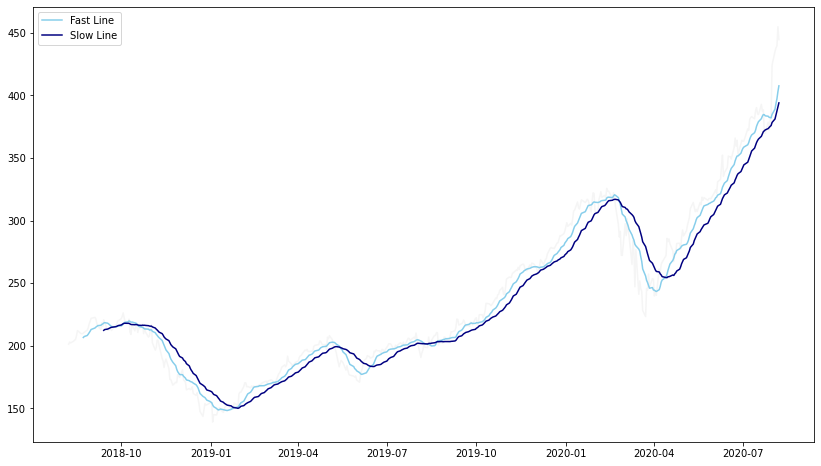

In [42]:
adj_close = aapl['Adj Close']

plt.figure(figsize=(14, 8))
plt.plot(adj_close, color='whitesmoke')
plt.plot(adj_close.rolling(12).mean(), color='skyblue', label='Fast Line')
plt.plot(adj_close.rolling(26).mean(), color='navy', label='Slow Line')
plt.legend();

---
# Back to the deck!
---

## Backshifting and Diffing
---
**Backshifting** values in a column is simply sliding all the values back a day. It's the operation, for each day $t$, of doing:

$$BX_t = X_{t - 1}$$
 
For example:

| Date | Price | Backshifted Price |
| --- | --- | --- |
| Jan 1 | 100 | _NaN_ |
| Jan 2 | 110 | 100 |
| Jan 3 | 105 | 110 |
| Jan 4 | 108 | 105 |

**Vocabulary:** Backshifting is sometimes called "lagging" and the new columns called "lags". For example, the new column created in the above example is the "first lag".

In [44]:
# Create a new column that's the backshifted "Open" column
aapl['open_lag1'] = aapl['Open'].shift()
aapl.head()

,Open,High,Low,Close,Adj Close,Volume,open_lag1
Date,,,,,,,
2018-08-08,206.050003,207.809998,204.520004,207.250000,201.371887,22525500,NaN
2018-08-09,209.529999,209.779999,207.199997,208.880005,202.955643,23492600,206.050003
2018-08-10,207.360001,209.100006,206.669998,207.529999,202.351089,24611200,209.529999
2018-08-13,209.309998,210.949997,207.699997,208.869995,203.657639,25890900,207.360001
2018-08-14,210.160004,210.559998,208.259995,209.750000,204.515747,20748000,209.309998


**Differencing** a column is taking today's value and subtracting yesterday's. Another way of putting it is subtracing today's value from today's _backshifted_ value. Mathematically, this is:

$$
\begin{align}
\nabla X_t &= X_t - X_{t - 1} \\
           &= X_t - BX_t
\end{align}
$$

For example:

| Date | Price | Backshifted Price | Diffed Price |
| --- | --- | --- | --- |
| Jan 1 | 100 | _NaN_ | _NaN_ |
| Jan 2 | 110 | 100 | 10 |
| Jan 3 | 105 | 110 | -5 |
| Jan 4 | 108 | 105 | 3 |

In [46]:
# Create a new column that's the diffed "Open" column.
# Then, create a new column that's "Open" minus the lagged column we made above. What do you notice?
aapl['open_diff'] = aapl['Open'].diff()
aapl['open_diff2'] = aapl['Open'] - aapl['open_lag1']
aapl.head()

,Open,High,Low,Close,Adj Close,Volume,open_lag1,open_diff,open_diff2
Date,,,,,,,,,
2018-08-08,206.050003,207.809998,204.520004,207.250000,201.371887,22525500,NaN,NaN,NaN
2018-08-09,209.529999,209.779999,207.199997,208.880005,202.955643,23492600,206.050003,3.479996,3.479996
2018-08-10,207.360001,209.100006,206.669998,207.529999,202.351089,24611200,209.529999,-2.169998,-2.169998
2018-08-13,209.309998,210.949997,207.699997,208.869995,203.657639,25890900,207.360001,1.949997,1.949997
2018-08-14,210.160004,210.559998,208.259995,209.750000,204.515747,20748000,209.309998,0.850006,0.850006


## You Try:

Create two **separate** plots:
* The closing price of AAPL over time
* The diffed closing price of AAPL over time

Specifications:
* Make sure the _x_-axes line up
* It must be one image with two separate graphs

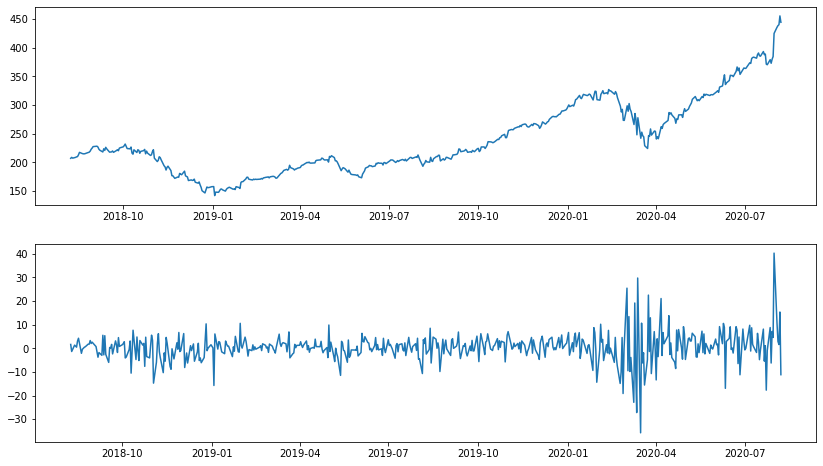

In [48]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(aapl['Close'])
axes[1].plot(aapl['Close'].diff());

# Stationarity

First, some new datasets.

In [57]:
# Population of Australia 1971-1994
aus = pd.read_csv('data/residents.csv')
aus.set_index(pd.to_datetime(aus.date), inplace=True)
aus.drop(columns='date', inplace=True)
aus.head()

,residents
date,
1971-04-01,13067.3
1971-07-01,13130.5
1971-10-01,13198.4
1972-01-01,13254.2
1972-04-01,13303.7


In [56]:
# Mean annual temperature (Fahrenheight) in New Haven, CT 1912-1971
nh = pd.read_csv('data/nhtemp.csv')
nh.set_index('year', inplace=True)
nh.head()

,temp
year,
1912,49.9
1913,52.3
1914,49.4
1915,51.1
1916,49.4


Plot these time series. Are they stationary? (We're just eye-balling stationarity for now, we'll have an official hypothesis test in the next lesson.)

If not... can you achieve stationarity after diffing?

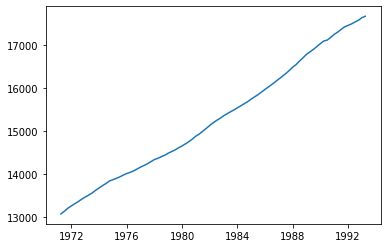

In [63]:
# Absolutely not! Clear upward trend.
plt.plot(aus);

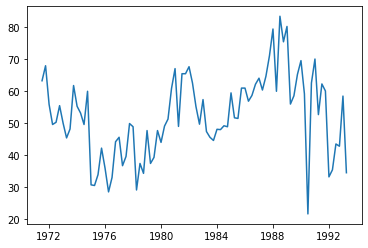

In [65]:
# Yeah, kinda!
plt.plot(aus.diff());

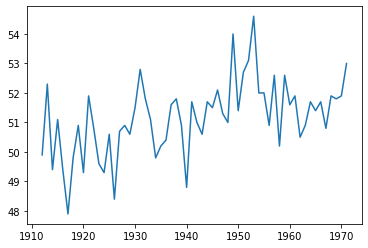

In [62]:
# Maybe! Seems trendless enough.
plt.plot(nh);

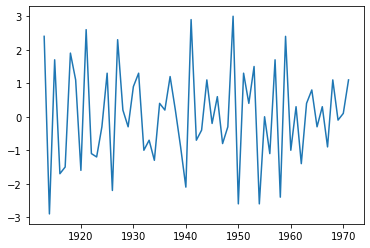

In [67]:
# Definitely after diffing once!
plt.plot(nh.diff());

# ACF and PACF
Explore the ACF and PACF graphs for both `aus` and `nh`. What do you notice about them?

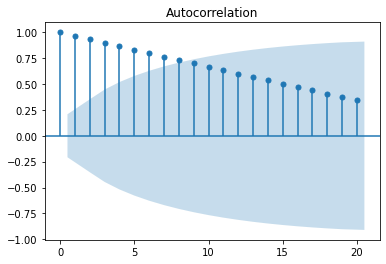

In [74]:
plot_acf(aus);

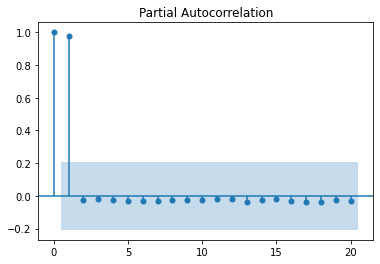

In [76]:
plot_pacf(aus);

The Australian population increases quickly over time - so we don't see any seasonal autocorrelation, but we do some steadily decreasing autocorrelation implying the upward trend. We also see only lag-1 partial autocorrelation since the lag-1 autocorrelation is independent of any lag-2 correlation.

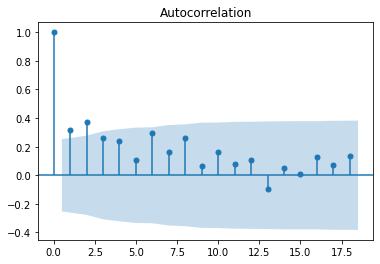

In [77]:
plot_acf(nh);

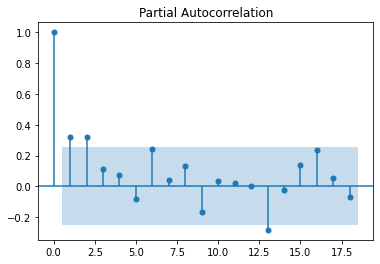

In [78]:
plot_pacf(nh);

The annual temperature in New Haven, CT doesn't increase or decrease over time and doesn't exhibit any seasonality. This is exhibited by no detectable [partial] autocorrelations.

## You Try: Lung disease data

Take a look at the lung disease data imported below. Look at its plot, ACF, and PACF. Can you explain the notable parts of each graph?

In [80]:
lung = pd.read_csv('data/lung-deaths.csv')
lung.date = pd.to_datetime(lung.date)
lung.set_index('date', inplace=True)
lung.head()

,deaths
date,
1974-01-01,3035
1974-02-01,2552
1974-03-01,2704
1974-04-01,2554
1974-05-01,2014


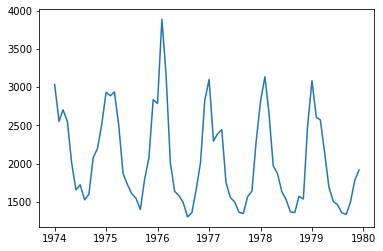

In [88]:
plt.plot(lung);

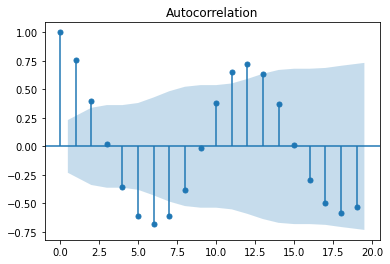

In [82]:
plot_acf(lung);

## BONUS CHALLENGE

For each year 1974 to 1979, plot the lung disease-related deaths on the same 12-month _x_-axis. Do you notice any interesting patterns?

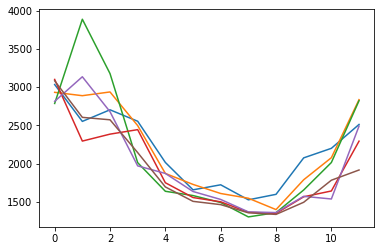

In [97]:
for y in range(1974, 1980):
    segment = lung.loc[str(y)].reset_index(drop=True)
    plt.plot(segment)

Yes! It appears that more deaths occur in colder months.

# Conclusions and Takeaways

* A **time series** is a series of observations taken in equally spaced intervals. Often this means days, months, quarters, or years.
* We have **dependent data** - we're very much concerned with row-to-row relationships and operation.
* Next, we'll focus on **forecasting** future observations!